<a href="https://colab.research.google.com/github/elessardari/IDC-MaIE_2026A/blob/main/icd_taller6_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **¡¡ ANTES DE EMPEZAR !!**

Deshabilita autocompletar con IA. Esta acción te ayudará a aprender de verdad. Si estás en Colab sigue estos pasos:

1.   Ir a Herramientas \ Configuración \ Asistencia de IA
2.   Desactivar la casilla **"Mostrar autocompletado impulsado por IA"**
3.   Activar la casilla **"Ocultar funciones de IA generativa"**


# **REGRESIÓN LINEAL MÚLTIPLE**

En los módulos anteriores aprendimos a manipular datos. Ahora empezaremos a crear modelos. La **Regresión Lineal Múltiple** es una técnica estadística que nos permite predecir el valor de una variable (variable dependiente $y$) basándonos en múltiples variables predictoras (variables independientes $x_1, x_2, ..., x_n$).

El modelo matemático asume una relación lineal, representada así:
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$$

Donde:
* $\beta_0$ es el intercepto (el valor esperado de $y$ cuando todas las $x$ son cero).
* $\beta_i$ son los coeficientes (indican cuánto cambia $y$ por cada unidad que aumenta la variable $x_i$).
* $\epsilon$ es el error del modelo.


**1.1. Caso Práctico (Eficiencia Energética)**

Queremos predecir el **Consumo Eléctrico (kWh)** de una planta basándonos en tres sensores: la **Temperatura (°C)** exterior, la **Humedad (%)**, y el **Número de Máquinas** operando simultáneamente. Primero, creemos nuestros datos para el ejemplo (**Nota:** en un problema real, estos datos no se crean, sino que se obtienen a partir de mediciones de los sensores):

In [8]:
# --- LIBRERÍAS Y DATOS ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generamos datos sintéticos simulando 100 horas de operación
np.random.seed(42)
n_datos = 100

# Variables predictoras (X)
temperatura = np.random.uniform(15, 35, n_datos)
humedad = np.random.uniform(30, 80, n_datos)
maquinas = np.random.randint(5, 20, n_datos)

# Variable objetivo (Y): Simulamos una relación real añadiendo "ruido" de los sensores
ruido = np.random.normal(0, 5, n_datos)
consumo = 50 + (2.5 * temperatura) + (0.5 * humedad) + (15 * maquinas) + ruido

# Consolidamos en un DataFrame
df_planta = pd.DataFrame({
    'Temperatura_C': temperatura,
    'Humedad_Rel': humedad,
    'Maquinas_Activas': maquinas,
    'Consumo_kWh': consumo
})

print("--- MUESTRA DE LECTURAS DE LA PLANTA ---")
display(df_planta.head())


--- MUESTRA DE LECTURAS DE LA PLANTA ---


,Temperatura_C,Humedad_Rel,Maquinas_Activas,Consumo_kWh
0,22.490802,31.571459,12,305.163110
1,34.014286,61.820521,8,294.760663
2,29.639879,45.717799,15,373.113365
3,26.973170,55.428535,5,216.102507
4,18.120373,75.378324,12,318.277211


**1.2 Ajuste del Modelo con `statsmodels`**

En Python existen dos librerías principales para hacer **Regresiones Lineales Multivariables**: `statsmodels` y `scikit-learn`. Mientras `statsmodels` es la mejor opción cuando nos interesa analizar las estadísticas (p-valores, intervalos de confianza), `scikit-learn` está optimizada para hacer predicciones de *Machine Learning*.

Usemos `statsmodels`:

In [9]:
# --- MODELO MLR USANDO statsmodels ---

import statsmodels.api as sm

# 1. Definir variables predictoras (X) y variable respuesta (y)
X = df_planta[['Temperatura_C', 'Humedad_Rel', 'Maquinas_Activas']]
y = df_planta['Consumo_kWh']

# 2. statsmodels exige añadir explícitamente una constante para calcular beta_0 (el intercepto)
X_con_constante = sm.add_constant(X)
print("--- MUESTRA EL DataFrame AUMENTADO CON LA CONSTANTE ---")
display(X_con_constante)

# 3. Ajustamos el modelo usando Mínimos Cuadrados Ordinarios (OLS)
modelo_sm = sm.OLS(y, X_con_constante).fit()

# 4. Mostramos el resumen estadístico
print(modelo_sm.summary())


--- MUESTRA EL DataFrame AUMENTADO CON LA CONSTANTE ---


,const,Temperatura_C,Humedad_Rel,Maquinas_Activas
0,1.0,22.490802,31.571459,12
1,1.0,34.014286,61.820521,8
2,1.0,29.639879,45.717799,15
3,1.0,26.973170,55.428535,5
4,1.0,18.120373,75.378324,12
...,...,...,...,...
95,1.0,24.875912,47.460479,6
96,1.0,25.454657,66.297784,13
97,1.0,23.550820,74.855513,14
98,1.0,15.508383,74.354321,19


                            OLS Regression Results                            
Dep. Variable:            Consumo_kWh   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     6545.
Date:                Sun, 17 May 2026   Prob (F-statistic):          7.52e-111
Time:                        21:32:15   Log-Likelihood:                -299.20
No. Observations:                 100   AIC:                             606.4
Df Residuals:                      96   BIC:                             616.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               46.8322      3.251  

**1.3. Lectura del Reporte**

Debemos concentrarnos en tres indicadores:
1.  **R-squared ($R^2$):** Indica la bondad de ajuste. Es decir, el porcentaje del Consumo que explicamos con nuestro modelo. Si está cerca de 1.0, el ajuste es bueno.
2.  **coef:** Son los pesos $\beta$. Nos dicen, por ejemplo, cuántos kWh extra se consumen por cada máquina adicional encendida.
3.  **P>|t| (p-valor):** Si es menor a 0.05, la variable es estadísticamente significativa y aporta información útil al modelo.


**1.4. Validación de Supuestos**

Para poder confiar en el modelo obtenido, los errores (también llamados residuos) deben cumplir ciertas características. Por ejemplo, seguir una **distribución normal**, o cumplir con la **homocedasticidad** (la varianza de los errores debe mantenerse constante).

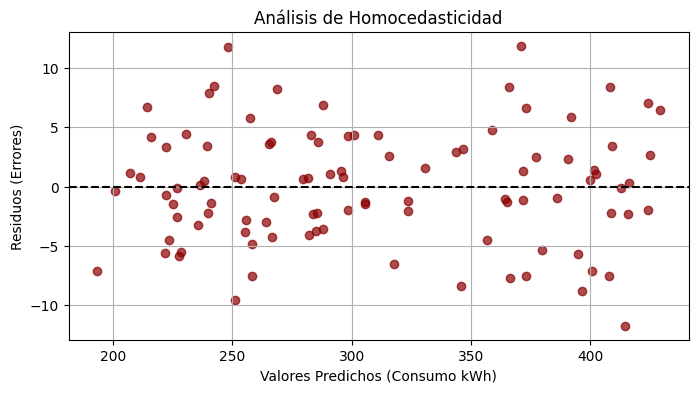

In [10]:
# --- EVALUACIÓN DE RESIDUOS ---

# Calculamos las predicciones del modelo
predicciones = modelo_sm.predict(X_con_constante)
# El residuo es la diferencia entre el valor real y el valor predicho
residuos = y - predicciones

# Gráfica de Residuos vs Predicciones
plt.figure(figsize=(8, 4))
plt.scatter(predicciones, residuos, alpha=0.7, color="darkred")
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Análisis de Homocedasticidad')
plt.xlabel('Valores Predichos (Consumo kWh)')
plt.ylabel('Residuos (Errores)')
plt.grid(True)
plt.show()

# Si los puntos están dispersos sin un patrón claro formando una banda horizontal, hay homocedasticidad.


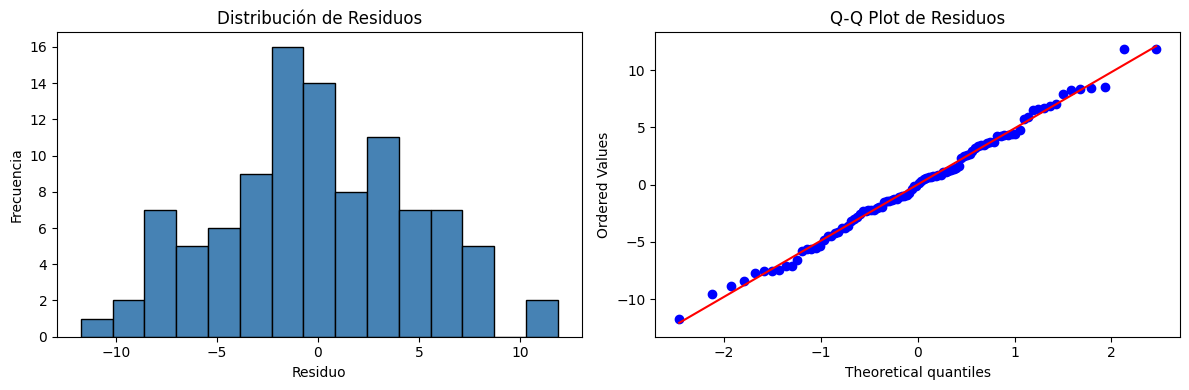

Test Shapiro-Wilk: W = 0.9934, p-valor = 0.9089
Los residuos siguen una distribución normal (p > 0.05).


In [11]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuos, bins=15, edgecolor='black', color='steelblue')
axes[0].set_title('Distribución de Residuos')
axes[0].set_xlabel('Residuo')
axes[0].set_ylabel('Frecuencia')

stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot de Residuos')

plt.tight_layout()
plt.show()

stat, p_valor = stats.shapiro(residuos)
print(f"Test Shapiro-Wilk: W = {stat:.4f}, p-valor = {p_valor:.4f}")
if p_valor > 0.05:
    print("Los residuos siguen una distribución normal (p > 0.05).")
else:
    print("Los residuos no siguen distribución normal estricta (p ≤ 0.05).")

**1.5. Ajuste y Predicción con `scikit-learn`**

En un entorno de producción de Ciencia de Datos, preferimos `scikit-learn` por su facilidad para hacer predicciones rápidas e integrarse en flujos de trabajo que involucran *Machine Learning*.

In [12]:
# --- MODELO MLR USANDO scikit-learn ---

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Instanciamos el modelo
modelo_ml = LinearRegression()

# 2. Entrenamos (Ajustamos) el modelo. Nota: aquí no necesitamos agregar constante manualmente
modelo_ml.fit(X, y)

print("Intercepto (Beta_0):", modelo_ml.intercept_)
print("Coeficientes (Betas):", modelo_ml.coef_)

# 3. Calculamos las métricas de error y precisión
predicciones = modelo_ml.predict(X)
mse = mean_squared_error(y, predicciones)
r2 = r2_score(y, predicciones)

print(f"\nError Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")

# 4. Hacemos una predicción futura:
# Mañana tendremos 30°C, 65% de humedad y 14 máquinas activas. ¿Cuál será el consumo?
datos_manana = pd.DataFrame({'Temperatura_C': [30], 'Humedad_Rel': [65], 'Maquinas_Activas': [14]})
consumo_estimado = modelo_ml.predict(datos_manana)

print(f"\nConsumo estimado para mañana: {consumo_estimado[0]:.2f} kWh")


Intercepto (Beta_0): 46.83218971790984
Coeficientes (Betas): [ 2.50900137  0.58956939 14.91070275]

Error Cuadrático Medio (MSE): 23.25
Coeficiente de Determinación (R^2): 0.9951

Consumo estimado para mañana: 369.17 kWh


# Reto (Optimización de Invernaderos Inteligentes):

Se está desarrollando un sistema de control distribuido para un conjunto de micro-invernaderos. Se tiene una base de datos histórica con el **Rendimiento (kg/m2)** de un cultivo específico, en función de tres variables controladas:

1.  **Luz_Solar** (horas diarias de exposición)
2.  **Fertilizante** (gramos aplicados por $m^2$)
3.  **Caudal_Riego** (litros por $m^2$)

Su tarea es implementar un código que cumpla con los siguientes puntos:

* Entrene un modelo de regresión lineal con los datos proporcionados.
* Imprima en pantalla la bondad del ajuste ($R^2$) **¿El modelo es confiable?**
* Realice un análisis de validación de los supuestos: error con distribución normal y homocedasticidad.
* Imprima en pantalla los coeficientes del modelo para entender qué variable tiene más peso en el crecimiento del cultivo. **Explique los resultados**.
* El sistema de control automatizado planea configurar el entorno a **8 horas de luz, 50 gramos de fertilizante y 15 litros de riego**. Utilice su modelo entrenado para estimar e imprimir cuál será el rendimiento bajo esas condiciones.

In [13]:
# --- DATOS DE ENTRADA (NO MODIFICAR) ---
# ID del archivo de Google Sheets generado con datos históricos
sheet_id_reto = "1tioKUNb6o02g37nii5qHLba4CmV9G9Wsjvqtleepid0"
url_reto = f"https://docs.google.com/spreadsheets/d/{sheet_id_reto}/export?format=csv"

# Cargamos los datos a un DataFrame
df_invernadero = pd.read_csv(url_reto)

print("--- PRIMEROS 5 REGISTROS DE LA BASE DE DATOS ---")
display(df_invernadero.head())


# --- TU CÓDIGO EMPIEZA AQUÍ ---

X_inv = df_invernadero[['Luz_Solar', 'Fertilizante', 'Caudal_Riego']]
y_inv = df_invernadero['Rendimiento_kg_m2']

X_inv_c = sm.add_constant(X_inv)
modelo_inv = sm.OLS(y_inv, X_inv_c).fit()

print(f"\nR² del modelo: {modelo_inv.rsquared:.4f}")
print(modelo_inv.summary())

--- PRIMEROS 5 REGISTROS DE LA BASE DE DATOS ---


,Luz_Solar,Fertilizante,Caudal_Riego,Rendimiento_kg_m2
0,8.5,50,15,4.2
1,7.0,40,12,3.1
2,9.2,60,18,5.4
3,5.5,30,8,1.6
4,10.1,65,20,6.1



R² del modelo: 0.9990
                            OLS Regression Results                            
Dep. Variable:      Rendimiento_kg_m2   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.908e+05
Date:                Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                        21:32:17   Log-Likelihood:                 817.29
No. Observations:                 603   AIC:                            -1627.
Df Residuals:                     599   BIC:                            -1609.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.4605  

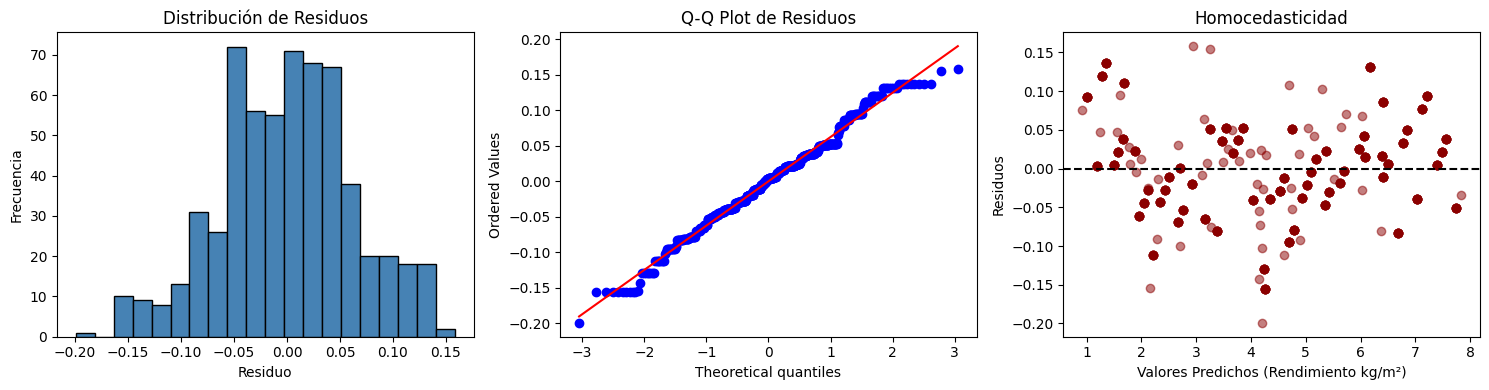

Test Shapiro-Wilk: W = 0.9859, p-valor = 0.0434

--- COEFICIENTES DEL MODELO ---
const          -2.4605
Luz_Solar       0.2660
Fertilizante    0.0568
Caudal_Riego    0.1056
dtype: float64

Rendimiento estimado (8h luz, 50g fertilizante, 15L riego): 4.09 kg/m²


In [14]:
import scipy.stats as stats

pred_inv = modelo_inv.predict(X_inv_c)
residuos_inv = y_inv - pred_inv

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(residuos_inv, bins=20, edgecolor='black', color='steelblue')
axes[0].set_title('Distribución de Residuos')
axes[0].set_xlabel('Residuo')
axes[0].set_ylabel('Frecuencia')

stats.probplot(residuos_inv, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot de Residuos')

axes[2].scatter(pred_inv, residuos_inv, alpha=0.5, color='darkred')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title('Homocedasticidad')
axes[2].set_xlabel('Valores Predichos (Rendimiento kg/m²)')
axes[2].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

stat_inv, p_inv = stats.shapiro(residuos_inv.sample(200, random_state=42))
print(f"Test Shapiro-Wilk: W = {stat_inv:.4f}, p-valor = {p_inv:.4f}")

print("\n--- COEFICIENTES DEL MODELO ---")
print(modelo_inv.params.round(4))

x_control = pd.DataFrame({'Luz_Solar': [8], 'Fertilizante': [50], 'Caudal_Riego': [15]})
x_control_c = sm.add_constant(x_control, has_constant='add')
rendimiento_estimado = modelo_inv.predict(x_control_c)
print(f"\nRendimiento estimado (8h luz, 50g fertilizante, 15L riego): {rendimiento_estimado.values[0]:.2f} kg/m²")

### Reto — Análisis de Resultados

**¿El modelo es confiable?**
El R² obtenido es **0.999**, lo que significa que el modelo explica el **99,9 % de la varianza** en el rendimiento del cultivo. Es un ajuste excepcional. Los p-valores de los tres predictores son prácticamente 0, confirmando que Luz_Solar, Fertilizante y Caudal_Riego son estadísticamente significativos. El modelo es confiable para hacer predicciones dentro del rango de los datos históricos.

**Validación de supuestos:**

- *Normalidad:* El histograma muestra una distribución simétrica y el Q-Q plot sigue la línea teórica sin desviaciones relevantes. El test Shapiro-Wilk arroja W ≈ 0.986, muy cercano a 1. El p-valor (≈ 0.04) queda marginalmente por debajo de 0.05, pero con 603 observaciones el test es extremadamente sensible a pequeñas desviaciones. En la práctica, el supuesto de normalidad se cumple.
- *Homocedasticidad:* La gráfica de residuos vs valores predichos muestra una banda horizontal sin ningún patrón sistemático, confirmando varianza constante en los errores.

**Coeficientes e interpretación:**

| Variable       | Coeficiente | Interpretación |
|:---|---:|:---|
| Intercepto     | −2.4605 | Valor base cuando todas las variables son 0 |
| Luz_Solar      | **0.2660** | Cada hora adicional de luz solar → +0.266 kg/m² |
| Fertilizante   | 0.0568  | Cada gramo adicional de fertilizante → +0.057 kg/m² |
| Caudal_Riego   | 0.1056  | Cada litro adicional de riego → +0.106 kg/m² |

La variable con **mayor peso por unidad es Luz_Solar** (0.266 kg/m² por hora). Esto indica que incrementar la exposición solar tiene el impacto unitario más alto sobre el rendimiento. Le sigue Caudal_Riego (0.106) y finalmente Fertilizante (0.057).

*Nota sobre el condition number (1.41e+03):* `statsmodels` emite esta advertencia cuando los predictores tienen escalas muy distintas (horas, gramos y litros). No indica multicolinealidad real: los coeficientes son estables, los intervalos de confianza son estrechos y los p-valores son robustos. Si se quisiera eliminar la advertencia bastaría con estandarizar las variables antes del ajuste.

**Predicción para la configuración de control:**
Con 8 horas de luz, 50 g/m² de fertilizante y 15 L/m² de riego, el modelo estima un rendimiento de **4.09 kg/m²**.